# Training of the c-ResUNet of Morelli et al. (2021) on Green (FNC v2) — Kaggle

Run `green_v2` of the development repository (`runs/cresunet/` in this repository).

Accelerator: **GPU T4 x2**. Inputs: the folders `cellseg-code` (code) and `fnc-green-data` (images and cleaned masks), found anywhere
under `/kaggle/input`. Full run: **Save Version → Save & Run All (Commit)**.

In [1]:
# 1) GPU disponibile?
import torch
print("torch", torch.__version__)
assert torch.cuda.is_available(), "Nessuna GPU: Settings → Accelerator → 'GPU T4 x2'"
print("GPU:", torch.cuda.get_device_name(0))

torch 2.10.0+cu128
GPU: Tesla T4


In [2]:
# 2) Trovo codice e dati sotto /kaggle/input e copio il codice in /kaggle/working
import os
import shutil
from pathlib import Path

INPUT = Path("/kaggle/input")
WORK = Path("/kaggle/working")

def find_one(pattern):
    """Primo percorso sotto /kaggle/input che corrisponde al pattern
    (Kaggle può annidare le cartelle dei dataset in modi diversi)."""
    hits = sorted(INPUT.rglob(pattern))
    assert hits, f"non trovato sotto {INPUT}: {pattern} — hai aggiunto i due dataset con 'Add Input'?"
    return hits[0]

CODE_SRC = find_one("models/c_res_unet_logits.py").parent.parent
IMAGES = find_one("green/trainval/images")
MASKS = find_one("cleaned_masks/trainval/Green/masks")
print("codice:  ", CODE_SRC)
print("immagini:", IMAGES, "→", len(list(IMAGES.glob("*.png"))), "png (attese 212)")
print("maschere:", MASKS, "→", len(list(MASKS.glob("*.png"))), "png (attese 213: la 128 non ha immagine)")

# /kaggle/input è in sola lettura: il codice va copiato in /kaggle/working e si lavora da lì
CODE = WORK / "code"
shutil.copytree(CODE_SRC, CODE, dirs_exist_ok=True)
os.chdir(CODE)
print("cartella di lavoro:", os.getcwd())

codice:   /kaggle/input/datasets/alixram/cell-segmentation/cellseg-code
immagini: /kaggle/input/datasets/alixram/cell-segmentation/fnc-green-data/green/trainval/images → 212 png (attese 212)
maschere: /kaggle/input/datasets/alixram/cell-segmentation/fnc-green-data/cleaned_masks/trainval/Green/masks → 213 png (attese 213: la 128 non ha immagine)
cartella di lavoro: /kaggle/working/code


## 3) Short check: 2 epochs

Commented out in this run. In its output, the first line must end with **`device cuda, amp True`**; the seconds
per epoch (end of each line) give the duration of the full training.

In [3]:
# !python -m train.training --images_dir "{IMAGES}" --masks_dir "{MASKS}" --split_json splits/green_split.json --out_dir /kaggle/working/runs/probe --epochs 2 --num_workers 4

## 4) Full training

c-ResUNet with the 5 × 5 residual block, 100 epochs with `--patience 100`, i.e. no early stopping. Output in `/kaggle/working/runs/green_v2/`:
`best.pt` (best validation Dice), `last.pt`, `log.csv`, `config.json`.

In [4]:
RUN_NAME = "green_v2"
!python -m train.training --images_dir "{IMAGES}" --masks_dir "{MASKS}" --split_json splits/green_split.json --out_dir /kaggle/working/runs/{RUN_NAME} --epochs 100 --patience 100 --num_workers 4

dati: 169 train, 43 val, caricati in 39 s | mean 0.0496 std 0.0699 | device cuda, amp True
ep   1 | lr 1.00e-03 | train loss 0.5529 | val loss 0.4891 dice 0.6575 | 72 s *
ep   2 | lr 1.00e-03 | train loss 0.3912 | val loss 0.4284 dice 0.7014 | 33 s *
ep   3 | lr 9.99e-04 | train loss 0.3580 | val loss 0.4155 dice 0.6900 | 34 s 
ep   4 | lr 9.98e-04 | train loss 0.3483 | val loss 0.4119 dice 0.7004 | 33 s 
ep   5 | lr 9.96e-04 | train loss 0.3498 | val loss 0.4241 dice 0.6916 | 34 s 
ep   6 | lr 9.94e-04 | train loss 0.3315 | val loss 0.4112 dice 0.6998 | 34 s 
ep   7 | lr 9.91e-04 | train loss 0.3248 | val loss 0.4278 dice 0.6941 | 34 s 
ep   8 | lr 9.88e-04 | train loss 0.3420 | val loss 0.4419 dice 0.6940 | 34 s 
ep   9 | lr 9.84e-04 | train loss 0.3216 | val loss 0.4280 dice 0.6784 | 34 s 
ep  10 | lr 9.80e-04 | train loss 0.3049 | val loss 0.3994 dice 0.7041 | 34 s *
ep  11 | lr 9.76e-04 | train loss 0.3013 | val loss 0.3513 dice 0.7442 | 34 s *
ep  12 | lr 9.70e-04 | train loss 0.

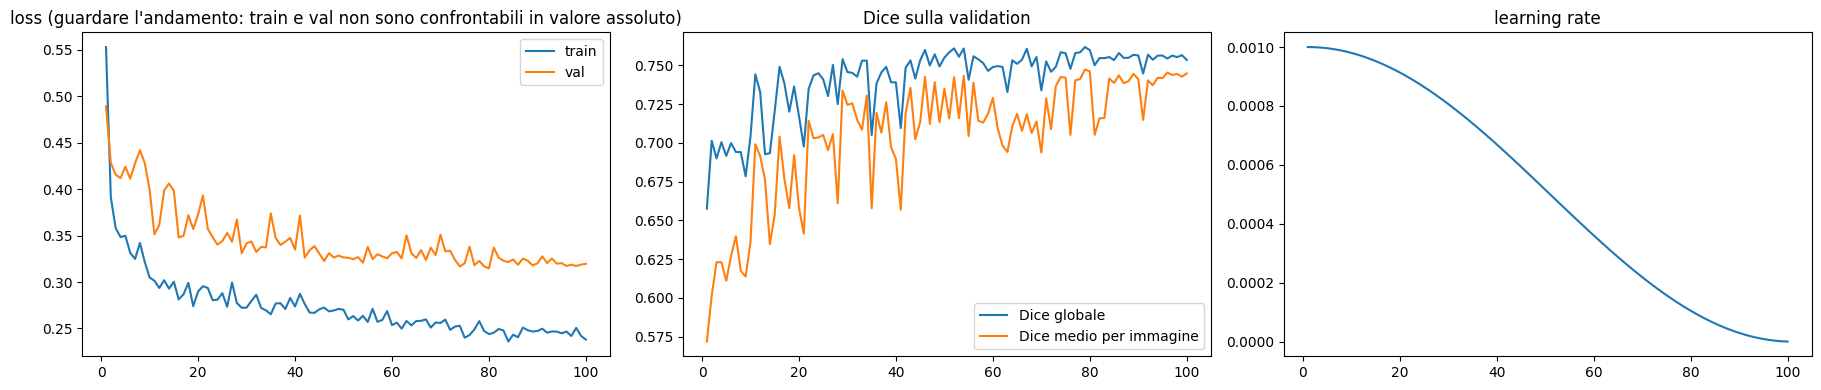

miglior epoca 79: Dice globale 0.7618 | IoU globale 0.6153 | Dice medio 0.7473
tempo medio per epoca: 34 s | epoche eseguite: 100


In [5]:
# 5) Curve di apprendimento
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv(f"/kaggle/working/runs/{RUN_NAME}/log.csv")
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(log.epoch, log.train_loss, label="train")
ax[0].plot(log.epoch, log.val_loss, label="val")
ax[0].set_title("loss (guardare l'andamento: train e val non sono confrontabili in valore assoluto)")
ax[0].legend()
ax[1].plot(log.epoch, log.val_dice_global, label="Dice globale")
ax[1].plot(log.epoch, log.val_dice_mean, label="Dice medio per immagine")
ax[1].set_title("Dice sulla validation")
ax[1].legend()
ax[2].plot(log.epoch, log.lr)
ax[2].set_title("learning rate")
plt.tight_layout()
plt.show()

best = log.loc[log.val_dice_global.idxmax()]
print(f"miglior epoca {int(best.epoch)}: Dice globale {best.val_dice_global:.4f} | IoU globale {best.val_iou_global:.4f} | "
      f"Dice medio {best.val_dice_mean:.4f}")
print(f"tempo medio per epoca: {log.time_s.mean():.0f} s | epoche eseguite: {len(log)}")